<a href="https://colab.research.google.com/github/hooveranna/symmetry_for_ML/blob/master/spherical_6_S966_S25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Companion Colab to `spherical` exercises for 6.S966 Spring 2025**

# All the imports and installs (sorry this takes a bit)

In [1]:
%%capture
!rm symm4ml_obfuscated.zip
!wget -O symm4ml_obfuscated.zip https://symm4ml.mit.edu/_static/symm4ml_s25/symm4ml/symm4ml_obfuscated_20250312.zip
!unzip -o symm4ml_obfuscated.zip
import sys
sys.path.append('/content/symm4ml_obfuscated')

In [ ]:
%%capture
!pip install pymatgen
!pip install e3nn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import symm4ml
from symm4ml import groups, linalg, rep, vis, vib_modes, lie, so3, grids

import e3nn
import e3nn.o3
import e3nn.io

import torch

import plotly
import plotly.graph_objects as go

# Plotting Spherical harmonics (with e3nn)
These cells go through the process of converting between the spherical harmonic conventions of `symm4ml` and `e3nn` codebases. It's not pretty, but it's good to know how to do.

### Get change of basis between `symm4ml` and `e3nn` irreps

In [ ]:
Lmax = 4
so3_irreps = lie.infer_irreps_from_tensor_products(so3.so3_gens, n=Lmax + 1)

In [ ]:
cob = []

# Generate random rotations
N = 10
rand_axis = np.random.randn(N, 3)
rand_axis = rand_axis / np.linalg.norm(rand_axis, 2, axis=-1, keepdims=True)
rand_axis_angles = np.pi * np.random.randn(N)
rand_signs = np.array([1] * int(N/2) + [-1] * int(N/2))

for L in range(Lmax + 1):
    p = (-1)**L

    # Generate e3nn irreps for random rotations
    ir_e3nn = e3nn.o3.Irrep('{L}{p}'.format(L=L, p='e' if p==1 else 'o'))
    rot_e3nn = ir_e3nn.D_from_axis_angle(
        torch.tensor(rand_axis, dtype=torch.float32),
        torch.tensor(rand_axis_angles, dtype=torch.float32)
    )
    if p == -1:
        rot_e3nn = rot_e3nn * rand_signs.reshape(-1, 1, 1)

    # Generate symm4ml irreps for random rotations
    ir_symm4ml = so3_irreps[L]
    rot_symm4ml = so3.o3_irrep(ir_symm4ml, rand_axis * rand_axis_angles.reshape(-1, 1), rand_signs, p)
    cob.append(linalg.infer_change_of_basis(rot_e3nn, rot_symm4ml))

cob = rep.direct_sum_multiple(cob).reshape((Lmax + 1)**2, (Lmax + 1)**2)

<ipython-input-5-5a29cf6ddebc>:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rot_e3nn = rot_e3nn * rand_signs.reshape(-1, 1, 1)


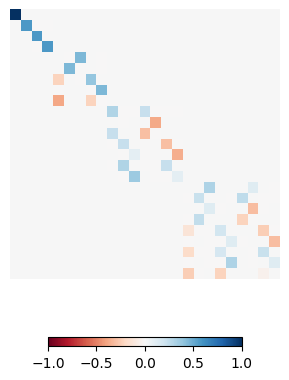

In [ ]:
vis.plot_matrices(cob[np.newaxis], cmap='RdBu', figsize=(5, 5));

### However, this change of basis is still not quite sufficient as there can still be blockwise sign differences...

In [ ]:
def compute_sign_correction_matrix(z_ref, z_target):
    """
    Compute a sign-correction matrix using blockwise dot products.

    Parameters:
        z_ref: reference spherical harmonic values (e.g. from e3nn), shape (N,)
        z_target: target values to align, shape (N,)

    Returns:
        sign_matrix: block-diagonal matrix of +/-1 to apply as cob @ sign_matrix
    """
    N = len(z_ref)
    lmax = int(np.sqrt(N) - 1)
    assert (lmax + 1) ** 2 == N, f"Expected full spectrum up to lmax={lmax}, got N={N}"

    block_sizes = [2 * l + 1 for l in range(lmax + 1)]

    signs = []
    idx = 0
    for size in block_sizes:
        block_ref = z_ref[idx:idx + size]
        block_target = z_target[idx:idx + size]
        sign = np.sign(np.dot(block_ref, block_target))
        signs.append(sign * np.ones([1, size, size]))
        idx += size

    return rep.direct_sum_multiple(signs).reshape(N, N)

In [ ]:
# Spherical harmonics in e3nn are normalized in the following way
sph_harm_normalization = lambda l : (2 * l + 1) * np.sqrt(1 / (4 * np.pi))
ls = np.array([l for l in range(Lmax + 1) for i in range(2 * l + 1)], dtype=np.float64)

z_symm4ml = ((cob @ np.concatenate(so3.spherical_harmonics(so3_irreps, np.array([0, 0, 1.])), axis=0)) * sph_harm_normalization(ls))
z_e3nn = e3nn.o3.spherical_harmonics([0, 1, 2, 3, 4], torch.tensor([0, 0., 1.]), normalize=True)

### Note, how these values match but differ in some places by a sign

In [ ]:
z_symm4ml.round(2), z_e3nn.numpy().round(2)

(array([ 0.28, -0.  ,  0.  ,  0.49, -0.  , -0.  , -0.32,  0.  ,  0.55,
         0.  , -0.  , -0.  ,  0.  ,  0.46, -0.  , -0.59,  0.  , -0.  ,
        -0.  ,  0.  , -0.32,  0.  ,  0.47, -0.  , -0.63]),
 array([ 0.28,  0.  ,  0.  ,  0.49,  0.  ,  0.  , -0.32,  0.  ,  0.55,
         0.  ,  0.  , -0.  , -0.  , -0.46,  0.  ,  0.59,  0.  ,  0.  ,
         0.  ,  0.  ,  0.32, -0.  , -0.47,  0.  ,  0.63], dtype=float32))

In [ ]:
xy_symm4ml = ((cob @ np.concatenate(so3.spherical_harmonics(so3_irreps, np.array([1, 1, 0.]) / np.sqrt(2)), axis=0)) * sph_harm_normalization(ls))
xy_e3nn = e3nn.o3.spherical_harmonics([0, 1, 2, 3, 4], torch.tensor([1, 1., 0.]) / np.sqrt(2), normalize=True)

In [ ]:
xy_symm4ml.round(2), xy_e3nn.numpy().round(2)

(array([ 0.28,  0.35,  0.35,  0.  ,  0.  ,  0.55,  0.16, -0.  , -0.27,
         0.21,  0.  , -0.48,  0.13, -0.  ,  0.51,  0.  ,  0.  ,  0.44,
         0.  , -0.17,  0.34, -0.  ,  0.59,  0.  , -0.16]),
 array([ 0.28,  0.35,  0.35,  0.  ,  0.  ,  0.55,  0.16,  0.  , -0.27,
        -0.21,  0.  ,  0.48, -0.13,  0.  , -0.51, -0.  , -0.  , -0.44,
         0.  ,  0.17, -0.34,  0.  , -0.59, -0.  ,  0.16], dtype=float32))

### Now we can use `cob_corrected` to change between `symm4ml.so3.spherical_harmonics` and `e3nn.o3.spherical_harmonics`

In [ ]:
sign_matrix = compute_sign_correction_matrix(xy_e3nn.numpy(), xy_symm4ml)
cob_corrected = cob * sign_matrix

xy_symm4ml_corrected = ((cob_corrected @ np.concatenate(
    so3.spherical_harmonics(so3_irreps, np.array([1, 1, 0.]) / np.sqrt(2)), axis=0)) * sph_harm_normalization(ls))

assert np.allclose(xy_symm4ml_corrected, xy_e3nn, atol=1e-4)

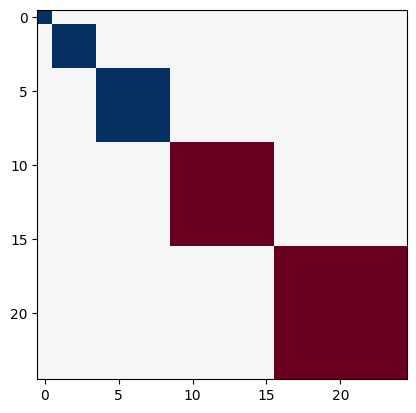

In [ ]:
plt.imshow(sign_matrix, cmap='RdBu', vmax=1, vmin=-1)

## Plotting spherical harmonics with `e3nn`

In [ ]:
# p_val is whether the signal has even or odd parity
# p_arg is whether the "vector" has even or odd parity
sph_ten = e3nn.io.SphericalTensor(lmax=Lmax, p_val=1, p_arg=-1)
# The pseudovector spherical harmonics would be
# e3nn.io.SphericalTensor(lmax=Lmax, p_val=-1, p_arg=-1)
e3nn_sh_rep = e3nn.o3.Irreps.spherical_harmonics(Lmax)
sig = torch.zeros(e3nn_sh_rep.dim)
sig[3] = 1 # z (l=1, m=1 -- real spherical harmonics)

In [ ]:
# radius=False, gives signal on sphere
go.Figure([
    go.Surface(**sph_ten.plotly_surface(sig, radius=False)[0])
])

In [ ]:
# radius=True, gives plot with radius == magnitude
go.Figure([
    go.Surface(**sph_ten.plotly_surface(sig, radius=True)[0])
])

#### Random spherical harmonic signal up to $L_\text{max} = 4$

In [ ]:
go.Figure([
    go.Surface(**sph_ten.plotly_surface(torch.randn(e3nn_sh_rep.dim), radius=True)[0])
])

In [ ]:
print(so3.project_discretized_function.__doc__)

Project a discretized function onto the first L spherical harmonics.
    Input:
        Xs: list of irreps of SO(3), from l=0, 1, 2, ... to l=L (each evaluated at the generators: therefore, an np.array [3, 2*l+1, 2*l+1])
        locations: a list of N unit vectors in R^3, i.e. each an np.array of size [3]
        values: an np.array of size [N], such that
            the input function f(x) = values[i] if x=locations[i], and f(x) is equal to 0 otherwise
    Output:
        sh: list of the spherical harmonic coefficients of f(x), from l=0, 1, 2, ... to l=L (each an np.array [2*l+1])
    Note:
        As normalisation, we normalise the spherical harmonics to have unit norm. (In other words, each output array in the list sh should have unit norm.)
    


## Project octahedron vertices onto sphere

In [ ]:
# octa = np.concatenate([np.eye(3), -np.eye(3)], axis=0)
octa = np.array([[0, 0, 1.]])
octa_sig_symm4ml = np.concatenate(so3.project_discretized_function(so3_irreps, octa, np.ones(len(octa))), axis=0)

# apply change of basis, spherical harmonic normalization and normalization factor for projection on sphere (same as e3nn)
s = cob_corrected @ octa_sig_symm4ml * sph_harm_normalization(ls) * 4 * np.pi / (Lmax + 1) ** 2
s.round(4)

array([ 0.1418, -0.    ,  0.    ,  0.2456, -0.    , -0.    , -0.1585,
        0.    ,  0.2746, -0.    ,  0.    ,  0.    , -0.    , -0.2297,
        0.    ,  0.2966, -0.    ,  0.    ,  0.    , -0.    ,  0.1595,
       -0.    , -0.2378,  0.    ,  0.3146])

In [ ]:
sph_ten.sum_of_diracs(torch.from_numpy(octa).to(torch.float32), torch.ones(len(octa)))

tensor([ 0.1418,  0.0000,  0.0000,  0.2456,  0.0000,  0.0000, -0.1585,  0.0000,
         0.2746,  0.0000,  0.0000,  0.0000,  0.0000, -0.2297,  0.0000,  0.2966,
         0.0000,  0.0000,  0.0000,  0.0000,  0.1595,  0.0000, -0.2378,  0.0000,
         0.3146])

In [ ]:
go.Figure([
    go.Surface(**sph_ten.plotly_surface(torch.from_numpy(s).to(torch.float32), radius=True)[0])
])

# (Problem 1) Generate O(3) irreps for elements of $O_h$ and $D_{2h}$

In [ ]:
lmax = 4
so3_irreps = lie.infer_irreps_from_tensor_products(so3.so3_gens, lmax + 1)

In [ ]:
Oh_gen = np.stack([
    -np.eye(3), # inversion
    so3.axis_angle_to_matrix(np.array([1., 0., 0.]), 2 * np.pi / 4), # 4-fold rotation around z
    so3.axis_angle_to_matrix(np.array([1., 1., 1.])/np.sqrt(3), 2 * np.pi / 3), # 3-fold rotation around [1, 1, 1]
], axis=0)

Oh = groups.generate_group(Oh_gen)
print("Oh vector rep: ", Oh.shape)

D2h_gen = np.stack([
    np.eye(3) * np.array([1, -1, 1]).reshape(1, 3), # mirror across y
    np.eye(3) * np.array([-1, 1, 1]).reshape(1, 3), # mirror across y
    so3.axis_angle_to_matrix(np.array([1., 0., 0.]), 2 * np.pi / 2), # 4-fold rotation around z
], axis=0)

D2h = groups.generate_group(D2h_gen)
print("D2h vector rep: ", D2h.shape)

Oh vector rep:  (48, 3, 3)
D2h vector rep:  (8, 3, 3)


In [ ]:
from scipy.spatial.transform import Rotation as R

np.random.seed(42)
N = 10
rand_rots = np.random.rand(N, 3) * 2 * np.pi
rand_signs = np.array([1] * int(N/2) + [-1] * int(N/2))

o3_irreps = []
o3_ir_labels = []
Lmax = 4
for L in range(Lmax+1):
    for p in [1, -1]:
        o3_irreps.append(so3.o3_irrep(so3_irreps[L], rand_rots, rand_signs, p))
        o3_ir_labels.append("{L}{p}".format(L=L, p="e" if p==1 else "o"))

dets = np.linalg.det(Oh)
rot = R.from_matrix(Oh * dets.reshape(-1, 1, 1))
rotvec = rot.as_rotvec()

o3_irreps_oh = []
Lmax = 4
for L in range(Lmax+1):
    for p in [1, -1]:
        o3_ir_labels += ['{L}{p}'.format(L=L, p='e' if p==1 else 'o')]
        o3_irreps_oh.append(so3.o3_irrep(so3_irreps[L], rotvec, dets, p))

dets = np.linalg.det(D2h)
rot = R.from_matrix(D2h * dets.reshape(-1, 1, 1))
rotvec = rot.as_rotvec()

o3_irreps_d2h = []
Lmax = 4
for L in range(Lmax+1):
    for p in [1, -1]:
        o3_irreps_d2h.append(so3.o3_irrep(so3_irreps[L], rotvec, dets, p))

print(o3_ir_labels)

['0e', '0o', '1e', '1o', '2e', '2o', '3e', '3o', '4e', '4o', '0e', '0o', '1e', '1o', '2e', '2o', '3e', '3o', '4e', '4o']


## Irreps of $O(3)$ Under $O_h$ and $D_{2h}$

In [ ]:
# trivial_irrep_oh = pass # YOUR CODE HERE
trivial_irrep_oh = np.ones([len(Oh), 1, 1])

for ir_label, ir in zip(o3_ir_labels, o3_irreps_oh):
    cob = linalg.infer_change_of_basis(ir, trivial_irrep_oh)
    print(ir_label, cob.shape)

0e (1, 1, 1)
0o (0, 1, 1)
1e (0, 3, 1)
1o (0, 3, 1)
2e (0, 5, 1)
2o (0, 5, 1)
3e (0, 7, 1)
3o (0, 7, 1)
4e (1, 9, 1)
4o (0, 9, 1)


In [ ]:
# trivial_irrep_d2h = pass # YOUR CODE HERE
trivial_irrep_d2h = np.ones([len(D2h), 1, 1])

for ir_label, ir in zip(o3_ir_labels, o3_irreps_d2h):
    cob = linalg.infer_change_of_basis(ir, trivial_irrep_d2h)
    print(ir_label, cob.shape)

0e (1, 1, 1)
0o (0, 1, 1)
1e (0, 3, 1)
1o (0, 3, 1)
2e (2, 5, 1)
2o (0, 5, 1)
3e (1, 7, 1)
3o (0, 7, 1)
4e (3, 9, 1)
4o (0, 9, 1)


# (Likely on next week's homework) Power- and Bi-spectra

## The power spectra for spherical harmonic signals up to $L_{\text{max}} = 4$ has 5 scalars.

In [ ]:
sh_rep_idx = [o3_ir_labels.index(label) for label in ['0e', '1o', '2e', '3o', '4e']]
sh_rep = rep.direct_sum_multiple([o3_irreps[i] for i in sh_rep_idx])
_, d, _ = sh_rep.shape
print(d)

25


In [ ]:
power_spectra_full = rep.tensor_product(sh_rep, sh_rep)

perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ij=ji')
new_basis, new_proj = grids.perm_and_sign_to_tensor_basis_and_proj(perm_rep, sign_rep, [d, d])

tp_sub = new_basis @ power_spectra_full @ new_basis.T
scalars_and_pseudoscalar = [o3_ir_labels.index(label) for label in ['0e', '0o']]
cob = [linalg.infer_change_of_basis(ir, tp_sub) for ir in [o3_irreps[i] for i in scalars_and_pseudoscalar]] # Check scalars and pseudoscalars
print([c.shape for c in cob])

[(5, 1, 325), (0, 1, 325)]


### Each scalar is generated from the norm of each L vector.

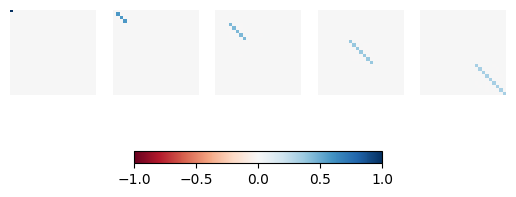

In [ ]:
scalar_cob = np.einsum('nsi,ij->nsj', cob[0], new_basis)
vis.plot_matrices(scalar_cob.reshape(-1, (Lmax+1)**2, (Lmax+1)**2), cmap='RdBu');

### The bispectra for spherical harmonic signals up to $L_\text{max} = 3$ has 8 scalars.

In [ ]:
# This takes a while.... would not recommend trying more than L_max = 3

sh_rep_idx = [o3_ir_labels.index(label) for label in ['0e', '1o', '2e', '3o']]
sh_rep = rep.direct_sum_multiple([o3_irreps[i] for i in sh_rep_idx])
_, d, _ = sh_rep.shape
print("Dimension of SH up to L_max = 3:", d)

bi_spectra_full = rep.tensor_product(rep.tensor_product(sh_rep, sh_rep), sh_rep)

Dimension of SH up to L_max = 3: 16


### This cell takes a few minutes to run...
Alas, the tradeoff between code that is easy to write vs. fast to execute!

In [ ]:
perm_rep, sign_rep = grids.formula_to_perm_and_sign_group('ijk=jik=ikj')
new_basis, new_proj = grids.perm_and_sign_to_tensor_basis_and_proj(perm_rep, sign_rep, [d, d, d])

tp_sub = new_basis @ bi_spectra_full @ new_basis.T
scalars_and_pseudoscalar = [o3_ir_labels.index(label) for label in ['0e', '0o']]
cob = [linalg.infer_change_of_basis(ir, tp_sub) for ir in [o3_irreps[i] for i in scalars_and_pseudoscalar]] # Check scalars and pseudoscalars
print([c.shape for c in cob])

[(8, 1, 816), (0, 1, 816)]


In [ ]:
scalar_cob = np.einsum('nsi,ij->nsj', cob[0], new_basis)

### The bispectrum is more complicated than the power spectrum, but essentially it exists when $L_1 \otimes L_2 \otimes L_3 = 0$ and paths don't become extinguished from permutation symmetry.

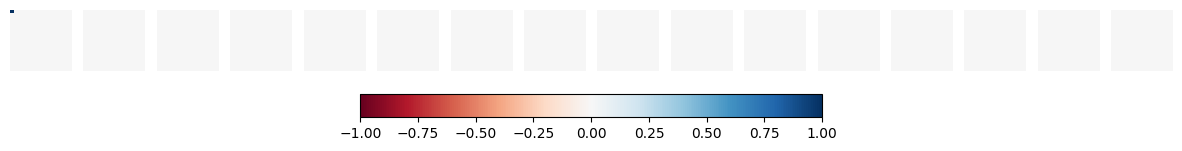

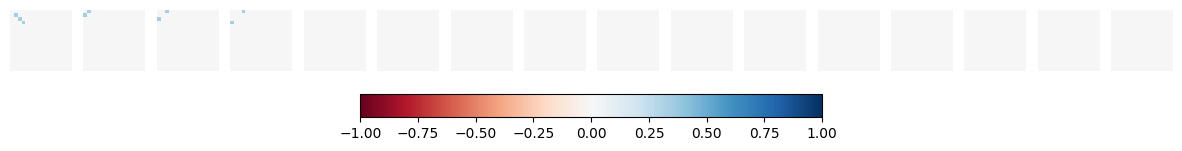

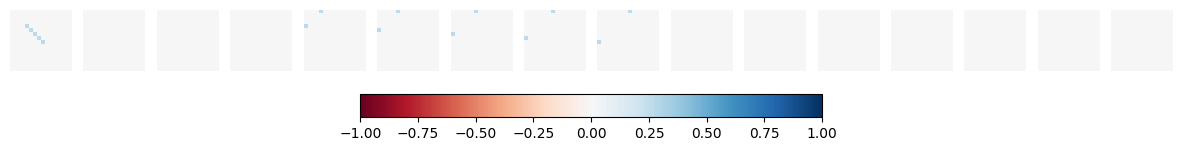

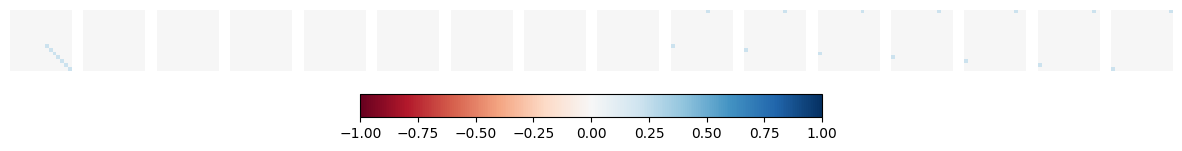

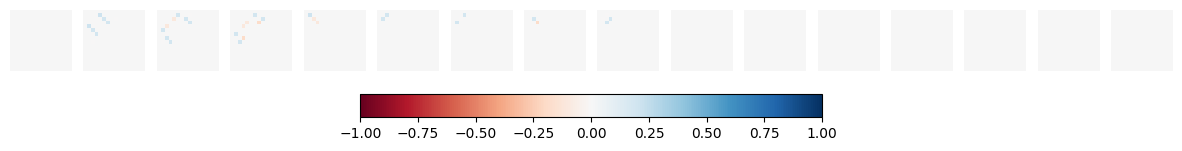

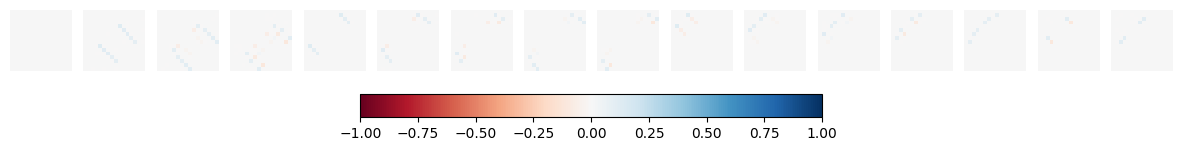

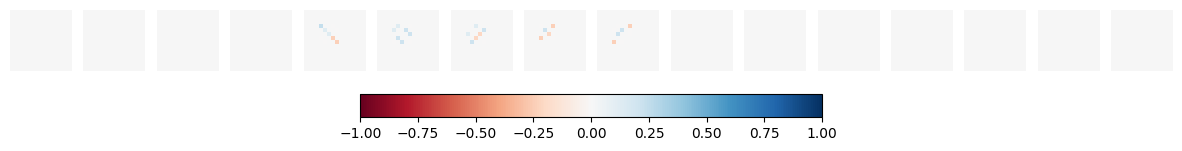

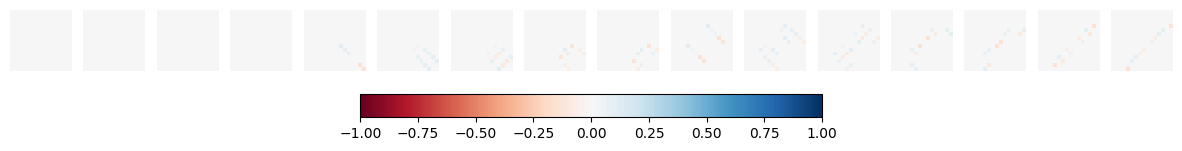

In [ ]:
for i in range(len(scalar_cob)):
  fig = vis.plot_matrices(scalar_cob[i].reshape((3+1)**2, (3+1)**2, (3+1)**2), cmap='RdBu', figsize=(15, 2));
  fig.show();

### In `e3nn-jax`, we are able to scale much better than our `symm4ml` approach.
## See the notebook here. (Link coming soon)